# 🐍 Python Level 3 - Advanced course
## Class 4 — Mini-Project — Supplier Payments Monitor
### 📝 Mini-Project

**Python instructor - Fábio Neves**

---

<div style="display:inline-flex; align-items:center; gap:28px; background:#FFFFFF; color:#1D1D1B; padding:10px 14px; border-radius:8px; margin-bottom:8px;">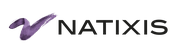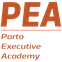</div>

---

---

## What you will build

A **payments monitor**: it holds every rule in a module, keeps the payments in a database, asks
the database questions, and finishes with two charts and a report.

This is the last class of the course, and it is deliberately the whole of it at once. Level 1
gave you the loop and pandas, Level 2 gave you functions, comprehensions and charts, Level 3
gave you databases, classes and modules. Today they all appear in one notebook.

```
   payments_tools.ipynb    part 1   the module: every rule
        │
        ▼
   Payment/ForeignPayment  part 2   the objects
        │
        ▼
   payments.db             part 3   stored with executemany
        │
        ▼
   SELECT ... GROUP BY     part 4   answered in SQL
        │
        ▼
   read_sql_query          part 5   back into pandas
        │
        ▼
   two charts              part 6   barh + pie, saved as PNG
        │
        ▼
   the report              part 7   calls only the module
```

> 🕐 You have the full session. The parts are in order and **each one leaves you with something
> that runs** — if you only reach part 4 you still have a working monitor.

> ⚠️ **Part 1 comes first for a reason.** Everything below it imports the module, so nothing
> will run until you have written it. Red cells before then are expected, not a mistake.

---

---
## The data

There is **no file to download**. The ten payments are written out for you in Part 2 — this
project is about what you do with them, not about loading them.

| Payment | Holds |
|---------|-------|
| `reference` | `PAY-001` … `PAY-010` |
| `supplier` | seven different suppliers, some paid more than once |
| `amount` | what was invoiced — in EUR, or in the supplier's own currency |
| `currency` + `rate` | foreign payments only: `USD` at `0.92`, `GBP` at `1.17` |

Seven of the ten are ordinary euro payments. Three are foreign: those are converted, and the
bank charges a fee on the conversion.

---

---
## Requirements

Your finished project must use all of these.

| # | Requirement | From class |
|---|-------------|-----------|
| 1 | A **module notebook**, imported with `import_ipynb` | L3C3 |
| 2 | Every rule (the fee, the threshold, the formatting) lives **in the module** | L3C3 |
| 3 | A **class** with `__init__` and methods | L3C2 |
| 4 | A **subclass**, using `super().__init__()` and **overriding** a method | L3C2 |
| 5 | A method that calls **`super()`** rather than repeating the parent | L3C2 |
| 6 | **`isinstance`** to count one kind of object | L3C2 |
| 7 | A table created with **`CREATE TABLE IF NOT EXISTS`**, cleared with `DELETE FROM` | L3C1 |
| 8 | **`executemany`** with `?` placeholders, then `commit()` | L3C1 |
| 9 | A **`GROUP BY`** query with `SUM`, `ORDER BY` and `LIMIT` | L3C1 |
| 10 | **`read_sql_query`** into a DataFrame, then `groupby` and `sort_values` | L3C1 + L1C3 |
| 11 | A **list comprehension** and a **set** | L1C2 + L2C2 |
| 12 | **`sorted` with a `lambda` key** | L2C2 |
| 13 | Two charts side by side, saved as a **PNG** | L2C3 |

> ⚠️ The one rule that matters most: **by Part 7, your notebook should contain no number that is
> a rule.** No `1.5`, no `1000`, no `:,.2f`. If you can see one, it belongs in the module.

---

## ⚙️ Setup

Run this first.

In [ ]:
!pip install -q import-ipynb
import import_ipynb

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
print("Setup complete")

---
## Part 1 — Write the module

**Open `payments_tools.ipynb`** — it sits beside this notebook — and follow the instructions in
it. It holds two values, a helper, `Payment`, `ForeignPayment(Payment)` and `summarise()`.

Then **run that notebook**, come back here, and run the cell below.

Expected output:
```
FEE_RATE: 1.5
LARGE   : 1000.0
PAY-000  Test Supplier       100.00 EUR
```

> ⚠️ If Python says `No module named 'payments_tools'`, the notebook is in a different folder,
> or you have not run it yet.
>
> ⚠️ If you change the module later, Python may keep using the old version. *Runtime → Restart
> session*, then run this notebook from the top.

In [ ]:
# Part 1 - a self-check: this only works once the module is written
import payments_tools

print("FEE_RATE:", payments_tools.FEE_RATE)
print("LARGE   :", payments_tools.LARGE)
print(payments_tools.Payment("PAY-000", "Test Supplier", 100.00).describe())

---
## Part 2 — Build the payments

The ten payments are below — that part is done for you. What you must add: count them, count
how many are **foreign** using `isinstance`, and count how many **different** suppliers there
are.

Expected output:
```
Payments : 10
Foreign  : 3
Suppliers: 7
```

> 💡 "How many different suppliers" is a **set** — Level 1 Class 2. Build it with a
> comprehension over `payment.supplier`.
>
> 💡 `isinstance(payment, ForeignPayment)` is `True` only for the foreign ones. Note that
> `isinstance(payment, Payment)` would be `True` for **all ten** — a `ForeignPayment` *is* a
> `Payment`.

In [ ]:
# Part 2
from payments_tools import Payment, ForeignPayment, format_eur

payments = [
    Payment("PAY-001", "Alpha Supplies", 1250.00),
    Payment("PAY-002", "Delta Services", 480.50),
    Payment("PAY-003", "Kestrel Print", 95.20),
    Payment("PAY-004", "Northwind Ltd", 640.00),
    Payment("PAY-005", "Riverbank Fuel", 310.75),
    Payment("PAY-006", "Alpha Supplies", 890.00),
    Payment("PAY-007", "Delta Services", 1120.00),
    ForeignPayment("PAY-008", "Cedar Timber", 1200.00, "USD", 0.92),
    ForeignPayment("PAY-009", "Nordic Paper", 750.00, "GBP", 1.17),
    ForeignPayment("PAY-010", "Cedar Timber", 400.00, "USD", 0.92),
]

# your three counts here

---
## Part 3 — Store them in a database

Open `payments.db`, create a `payments` table with four columns — `reference`, `supplier`,
`total`, `kind` — clear it, then insert all ten with **one** `executemany` call. Commit, then
count the rows to prove it worked.

Expected output:
```
Rows stored: 10
```

> 💡 Build the rows with a **list comprehension** that asks each object for its own values:
> `(payment.reference, payment.supplier, payment.total(), payment.kind())`.
>
> 💡 This is the payoff for having written the classes. You never ask *"is this one foreign?"* —
> each object already knows its own total and its own kind.
>
> ⚠️ `CREATE TABLE IF NOT EXISTS`, then `DELETE FROM`, or your rows double every time you re-run
> the cell.

In [ ]:
# Part 3

---
## Part 4 — Ask the database questions

Three questions, all answered in **SQL** rather than in Python:

1. The **top three suppliers** by total paid — `GROUP BY`, `SUM`, `ORDER BY`, `LIMIT`
2. The **single largest** payment: its reference, supplier and total
3. How many payments are **foreign** — using a `?` placeholder, not the word in the query

Expected output:
```
Top 3 suppliers
  Alpha Supplies    2,140.00 EUR
  Delta Services    1,600.50 EUR
  Cedar Timber      1,494.08 EUR

Largest  : PAY-001 to Alpha Supplies, 1,250.00 EUR
Foreign  : 3
```

> 💡 `SUM(total) AS paid` names the total so `ORDER BY paid DESC` can use it.
>
> 💡 `fetchone()` returns one row as a tuple, which you can unpack:
> `reference, supplier, total = cursor.fetchone()`.
>
> 💡 The blank line before `Largest` comes from `\n` at the start of that f-string.

In [ ]:
# Part 4

---
## Part 5 — Back into pandas

Read the whole table into a DataFrame with `read_sql_query`. Then print the total paid per
supplier, largest first, and work out what **share of all the money** went abroad.

Expected output:
```
supplier
Alpha Supplies    2140.00
Delta Services    1600.50
Cedar Timber      1494.08
Nordic Paper       890.66
Northwind Ltd      640.00
Riverbank Fuel     310.75
Kestrel Print       95.20
Name: total, dtype: float64

Share foreign: 33.3 %
```

> 💡 `frame.groupby("supplier")["total"].sum().round(2).sort_values(ascending=False)`.
>
> 💡 For the share: filter to `kind == "foreign"`, sum that, divide by the sum of everything,
> times 100, rounded to 1 decimal.
>
> 💡 Part 4 and Part 5 answer the same kind of question two ways. Both are worth knowing: SQL
> when the database should do the work, pandas when you want to keep working on the answer.

In [ ]:
# Part 5

---
## Part 6 — Two charts

One figure, two charts side by side, saved as `payments_monitor.png`:

- **left** — a horizontal bar chart of total paid per supplier
- **right** — a pie chart of domestic against foreign

Give each a title, label the bar chart's axis in EUR, and use `tight_layout()`.

> 💡 `plt.figure(figsize=(13, 4.5))`, then `plt.subplot(1, 2, 1)` and `plt.subplot(1, 2, 2)` —
> the same pattern as the Level 2 dashboard, one row of two instead of a 2x2 grid.
>
> 💡 `barh` draws its first row at the **bottom**, so sort the other way round for the chart if
> you want the biggest supplier at the top.
>
> 💡 `autopct="%1.1f%%"` puts the percentages on the pie slices.

In [ ]:
# Part 6

---
## Part 7 — The report

Print the finished report: every payment, largest first, then the four summary figures.

Expected output:
```
SUPPLIER PAYMENTS MONITOR
----------------------------------------------------------
PAY-001  Alpha Supplies    1,250.00 EUR  LARGE
PAY-008  Cedar Timber      1,120.56 EUR  LARGE   (1,200.00 USD)
PAY-007  Delta Services    1,120.00 EUR  LARGE
PAY-009  Nordic Paper        890.66 EUR   (750.00 GBP)
PAY-006  Alpha Supplies      890.00 EUR
PAY-004  Northwind Ltd       640.00 EUR
PAY-002  Delta Services      480.50 EUR
PAY-010  Cedar Timber        373.52 EUR   (400.00 USD)
PAY-005  Riverbank Fuel      310.75 EUR
PAY-003  Kestrel Print        95.20 EUR
----------------------------------------------------------
Payments  : 10
Total     : 7,171.19 EUR
Average   : 717.12 EUR
Largest   : 1,250.00 EUR
```

Then `connection.close()`.

> 💡 `sorted(payments, key=lambda payment: payment.total(), reverse=True)`.
>
> 💡 The separator is `"-" * 58`, and the labels are padded to 10 characters before the colon.
>
> 💡 **Look at PAY-008.** It is marked `LARGE` even though it was invoiced in dollars — because
> `is_large()` asks `total()`, and the foreign `total()` includes the conversion and the fee. You
> wrote `is_large()` once, on the parent, and it is right for both. That is the point of Part 1.
>
> ⚠️ Read your finished cell back. **No fee, no threshold, no `:,.2f`.** Only the data, a loop,
> and calls into the module.

In [ ]:
# Part 7

---
## 🌟 Stretch goals

Only if you have finished everything above and it all runs.

1. **A third kind of payment.** Add `RecurringPayment(Payment)` for something billed monthly:
   it takes a `months` argument, and its `total()` is the amount times the months. Add one to
   the list — everything else should keep working with no changes at all. That is the test of
   whether your design is right.
2. **A query with a parameter.** Write a function `paid_to(supplier)` that runs a `SELECT` with
   a `?` placeholder and returns the total for that supplier.
3. **Save the summary.** Write the per-supplier totals out with `to_csv`, then read them back
   with `read_csv` to check.
4. **Put it in the module.** Move the report printing into `payments_tools.ipynb` as
   `print_report(payments)`, so this notebook becomes seven lines that call things.

---
## 💡 If you get stuck

| Problem | Look at |
|---------|---------|
| `No module named 'payments_tools'` | is it in the same folder? did you run it? |
| Changes to the module are ignored | *Runtime → Restart session*, then run from the top |
| The totals double each run | you are missing `DELETE FROM payments` |
| `ForeignPayment` totals look wrong | convert first, **then** take the fee off the converted figure |
| Both classes print the same line | `ForeignPayment` needs its own `describe()`, calling `super().describe()` |
| `no such table: payments` | Part 3's cell has not run in this session |

> 🕐 **If you are running out of time**, Parts 1-4 are the core: the module, the classes and the
> database. Parts 5-7 are the polish.

➡️ The solution will be shared after the class. Try everything first — the point is the attempt.